# AUM growth — grouped bar by fund house (2022–2025)
Grouped bar chart using **Seaborn**. **SBI Mutual Fund** is highlighted and annotated for dominance around **₹12.5L Cr**.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- repo-root detection (works from any notebook working directory) ---
_HERE = Path(__file__).resolve() if '__file__' in globals() else Path.cwd()

def _find_repo_root(start: Path) -> Path:
    cand = start
    for _ in range(10):
        if (cand / 'Data' / 'processed' / 'aum_by_fund_house_clean.csv').exists():
            return cand
        if cand.name == 'notebooks':
            parent = cand.parent
            if (parent / 'Data' / 'processed' / 'aum_by_fund_house_clean.csv').exists():
                return parent
        cand = cand.parent
    return start.parent

_REPO_ROOT = _find_repo_root(_HERE)
DATA_PATH = _REPO_ROOT / 'Data' / 'processed' / 'aum_by_fund_house_clean.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing file: {DATA_PATH.resolve()}')

aum_df = pd.read_csv(DATA_PATH)
aum_df['date'] = pd.to_datetime(aum_df['date'], errors='coerce')
aum_df['year'] = aum_df['date'].dt.year
aum_df['aum_lakh_crore'] = pd.to_numeric(aum_df['aum_lakh_crore'], errors='coerce')

YEARS = [2022, 2023, 2024, 2025]
aum_df = aum_df[aum_df['year'].isin(YEARS)].copy()

# Pick snapshot date per (year, fund_house): prefer year-end like 12-31, else last available in that year.
preferred_md = {('12', '31'), ('09', '30'), ('03', '31')}
aum_df['mm'] = aum_df['date'].dt.strftime('%m')
aum_df['dd'] = aum_df['date'].dt.strftime('%d')
aum_df['is_preferred'] = aum_df[['mm', 'dd']].apply(tuple, axis=1).isin(preferred_md)

def _pick_snapshot(g: pd.DataFrame) -> pd.Series:
    pref = g[g['is_preferred']]
    if not pref.empty:
        return pref.sort_values('date').iloc[-1]
    return g.sort_values('date').iloc[-1]

snapshot_df = (
    aum_df.groupby(['year', 'fund_house'], as_index=False, group_keys=False)
    .apply(_pick_snapshot)
    .reset_index(drop=True)
)

plot_df = (
    snapshot_df.groupby(['year', 'fund_house'], as_index=False)
    .agg(aum_lakh_crore=('aum_lakh_crore', 'sum'))
)

SBI_NAME = 'SBI Mutual Fund'
if SBI_NAME not in set(plot_df['fund_house'].unique()):
    raise ValueError('SBI Mutual Fund not found in dataset')

# Dominance per year
total_by_year = plot_df.groupby('year', as_index=False)['aum_lakh_crore'].sum().rename(columns={'aum_lakh_crore': 'total_aum_lakh_crore'})
sbi_by_year = plot_df[plot_df['fund_house'] == SBI_NAME][['year', 'aum_lakh_crore']].rename(columns={'aum_lakh_crore': 'sbi_aum_lakh_crore'})
dominance_df = sbi_by_year.merge(total_by_year, on='year', how='left')
dominance_df['sbi_dominance_pct'] = 100.0 * dominance_df['sbi_aum_lakh_crore'] / dominance_df['total_aum_lakh_crore']

Y_HIGHLIGHT = 2025
dom_2025 = dominance_df.loc[dominance_df['year'] == Y_HIGHLIGHT].iloc[0]
print('SBI dominance by year (snapshot-based):')
print(dominance_df.sort_values('year').to_string(index=False))


SBI dominance by year (snapshot-based):
 year  sbi_aum_lakh_crore  total_aum_lakh_crore  sbi_dominance_pct
 2022                6.30                 30.90          20.388350
 2023                8.45                 37.42          22.581507
 2024               11.14                 52.68          21.146545
 2025               12.50                 62.74          19.923494


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_30020\3164437637.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_pick_snapshot)


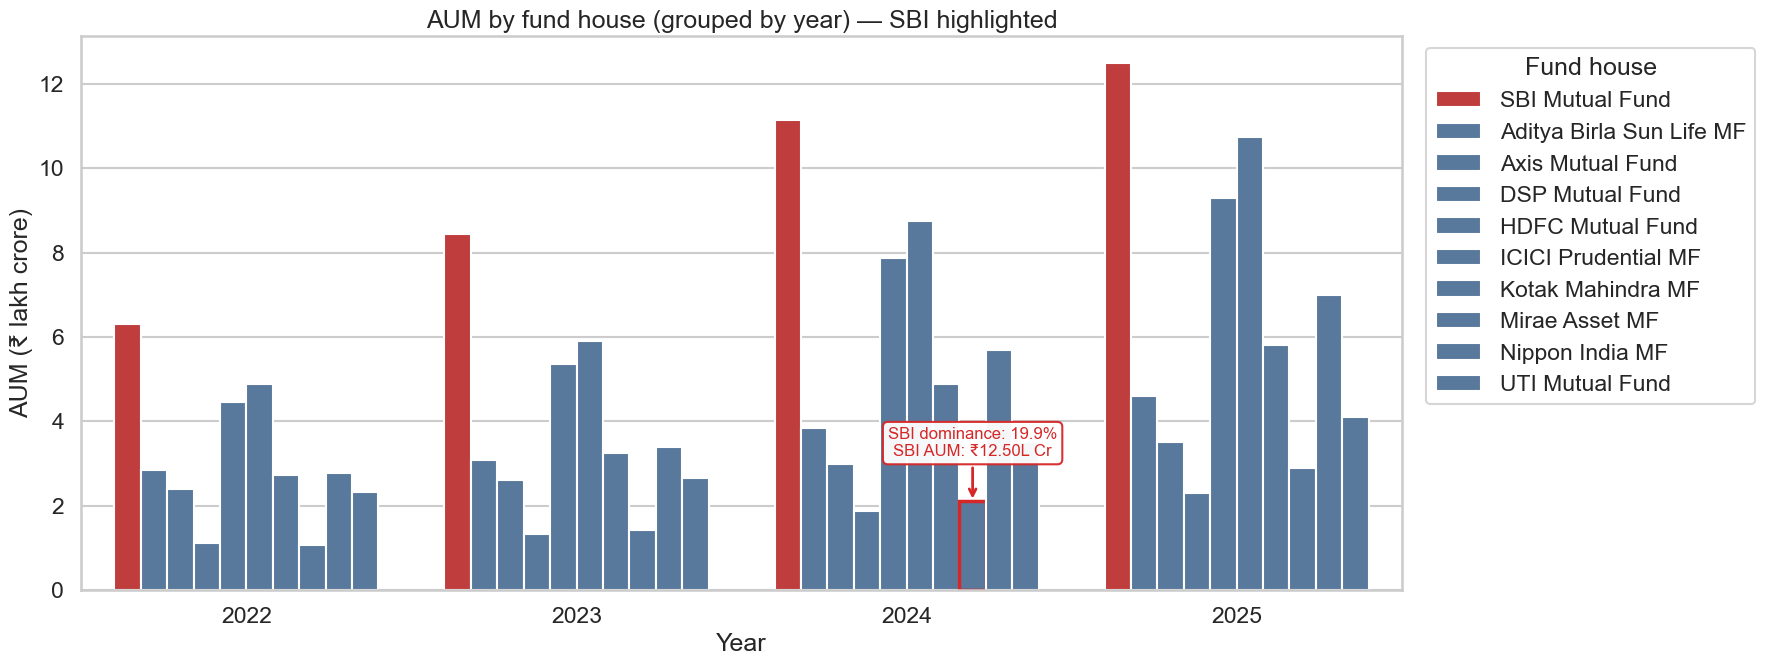

In [2]:
sns.set_theme(style='whitegrid', context='talk')

fund_houses = plot_df['fund_house'].unique().tolist()
fund_houses_sorted = sorted([fh for fh in fund_houses if fh != SBI_NAME])
hue_order = [SBI_NAME] + fund_houses_sorted
palette = {fh: ('#d62728' if fh == SBI_NAME else '#4c78a8') for fh in hue_order}

fig, ax = plt.subplots(figsize=(18, 7))

sns.barplot(
    data=plot_df,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house',
    order=YEARS,
    hue_order=hue_order,
    palette=palette,
    dodge=True,
    ax=ax
)

ax.set_title('AUM by fund house (grouped by year) — SBI highlighted')
ax.set_xlabel('Year')
ax.set_ylabel('AUM (₹ lakh crore)')

# Legend cleanup (keep SBI + first few others if too many)
handles, labels = ax.get_legend_handles_labels()
if len(labels) > 10:
    keep_labels = [SBI_NAME] + [lb for lb in labels if lb != SBI_NAME][:9]
    keep_idx = [labels.index(lb) for lb in keep_labels if lb in labels]
    ax.legend([handles[i] for i in keep_idx], [labels[i] for i in keep_idx],
              title='Fund house', loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True)
else:
    ax.legend(title='Fund house', loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True)

# Highlight/annotate SBI 2025 bar
patches = ax.patches
num_hues = len(hue_order)
year_idx = YEARS.index(Y_HIGHLIGHT)
sbi_hue_idx = hue_order.index(SBI_NAME)
patch_index = year_idx * num_hues + sbi_hue_idx

if patch_index < len(patches):
    patch = patches[patch_index]
    x_center = patch.get_x() + patch.get_width() / 2
    y_top = patch.get_height()

    dominance_text = (
        f'SBI dominance: {dom_2025["sbi_dominance_pct"]:.1f}%\n'
        f'SBI AUM: ₹{dom_2025["sbi_aum_lakh_crore"]:.2f}L Cr'
    )

    ax.annotate(
        dominance_text,
        xy=(x_center, y_top),
        xytext=(x_center, y_top + plot_df['aum_lakh_crore'].max() * 0.08),
        ha='center',
        va='bottom',
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d62728', alpha=0.95),
        arrowprops=dict(arrowstyle='->', color='#d62728', lw=2),
        color='#d62728'
    )

    patch.set_edgecolor('#d62728')
    patch.set_linewidth(2.5)
else:
    print('Warning: could not locate SBI 2025 patch for annotation (unexpected patch ordering).')

plt.tight_layout()
plt.show()
